# Traffic Detection Pipeline: End-to-End Implementation

## 1. Phase I Recap: Initial Dataset & Limitations
In Phase I of this project, we began with a curated subset of the BDD100K dataset, formatted in YOLO structure. Our initial scope was limited to 4 primary traffic classes (`Car`, `Pedestrian`, `Traffic Light`, `Traffic Sign`). 

While our initial Pandas preprocessing, statistical cleaning (IQR bounding box analysis), and visual diagnostics proved that the pipeline worked, we realized a 4-class system was insufficient for a robust, real-world autonomous driving application. 

## 2. Dataset Upgrade & Integration
To build a production-grade model, we vastly upgraded our dataset pipeline:
* **Added UA-DETRAC:** We merged high-density traffic camera footage to reinforce vehicle detection.
* **Roboflow Ingestion:** We used Roboflow to standardize annotations across both datasets.
* **Expanded Classes:** We expanded our detection capabilities to **10 distinct classes**:
`['bike', 'bus', 'car', 'motor', 'person', 'rider', 'traffic light', 'traffic sign', 'train', 'truck']`

---
## 3. Data Preprocessing & Merging
Because the data was exported from Roboflow in distinct batches (BDD100k and UA-DETRAC), we engineered two custom Python scripts to programmatically handle the data.

1. **`merge_datasets.py`**: Maps the disparate class IDs into a unified 10-class structure and merges the images/labels into a single `master_dataset`.
2. **`convert_to_voc.py`**: Converts the YOLO `.txt` labels into PASCAL VOC `.xml` format, which is strictly required for training our PyTorch SSD architecture.

In [ ]:
# merge_datasets.py (Executed via terminal during preprocessing)
import os
import shutil

target_classes = [
    'bike', 'bus', 'car', 'motor', 'person', 
    'rider', 'traffic light', 'traffic sign', 'train', 'truck'
]

bdd_map = {
    0: 0, 1: 1, 2: 2, 5: 3, 6: 4, 
    7: 5, 8: 6, 9: 7, 10: 8, 11: 9
}

detrac_map = {0: 2, 1: 1, 2: 9}

def process_dataset(source_dir, dest_dir, class_map, split_name):
    os.makedirs(f"{dest_dir}/{split_name}/images", exist_ok=True)
    os.makedirs(f"{dest_dir}/{split_name}/labels", exist_ok=True)

    images_dir = f"{source_dir}/{split_name}/images"
    if not os.path.exists(images_dir):
        return

    for img_name in os.listdir(images_dir):
        base_name = os.path.splitext(img_name)[0]
        txt_name = f"{base_name}.txt"
        
        img_src = f"{images_dir}/{img_name}"
        txt_src = f"{source_dir}/{split_name}/labels/{txt_name}"

        if not os.path.exists(txt_src): 
            continue

        valid_lines = []
        with open(txt_src, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                    
                old_id = int(parts[0])
                if old_id in class_map:
                    new_id = class_map[old_id]
                    parts[0] = str(new_id)
                    valid_lines.append(" ".join(parts))

        if valid_lines:
            shutil.copy(img_src, f"{dest_dir}/{split_name}/images/{img_name}")
            with open(f"{dest_dir}/{split_name}/labels/{txt_name}", 'w') as f:
                f.write("\n".join(valid_lines) + "\n")

In [ ]:
# convert_to_voc.py (Executed via terminal during preprocessing)
import cv2
import xml.etree.ElementTree as ET
from xml.dom import minidom

def create_voc_xml(img_path, txt_path, xml_path, folder_name):
    img = cv2.imread(img_path)
    if img is None: return False
    height, width, depth = img.shape

    annotation = ET.Element('annotation')
    ET.SubElement(annotation, 'folder').text = folder_name
    ET.SubElement(annotation, 'filename').text = os.path.basename(img_path)
    
    size = ET.SubElement(annotation, 'size')
    ET.SubElement(size, 'width').text = str(width)
    ET.SubElement(size, 'height').text = str(height)
    ET.SubElement(size, 'depth').text = str(depth)
    
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                
                class_id = int(parts[0])
                class_name = target_classes[class_id]
                
                x_center, y_center, w, h = map(float, parts[1:5])
                
                xmin = max(1, int((x_center - (w / 2)) * width))
                ymin = max(1, int((y_center - (h / 2)) * height))
                xmax = min(width - 1, int((x_center + (w / 2)) * width))
                ymax = min(height - 1, int((y_center + (h / 2)) * height))

                obj = ET.SubElement(annotation, 'object')
                ET.SubElement(obj, 'name').text = class_name
                ET.SubElement(obj, 'pose').text = 'Unspecified'
                ET.SubElement(obj, 'truncated').text = '0'
                ET.SubElement(obj, 'difficult').text = '0'
                
                bndbox = ET.SubElement(obj, 'bndbox')
                ET.SubElement(bndbox, 'xmin').text = str(xmin)
                ET.SubElement(bndbox, 'ymin').text = str(ymin)
                ET.SubElement(bndbox, 'xmax').text = str(xmax)
                ET.SubElement(bndbox, 'ymax').text = str(ymax)

    xmlstr = minidom.parseString(ET.tostring(annotation)).toprettyxml(indent="   ")
    with open(xml_path, 'w') as f:
        f.write(xmlstr)
    return True

---
## 4. Exploratory Data Analysis (EDA) on the Upgraded Dataset
With 10 classes, it is critical to understand our class distribution. Dashcam datasets inherently suffer from severe class imbalance, which can heavily impact model training.

C:\Users\DELL\AppData\Local\Temp\ipykernel_6500\2234555607.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class_name', order=df['class_name'].value_counts().index, palette='viridis')


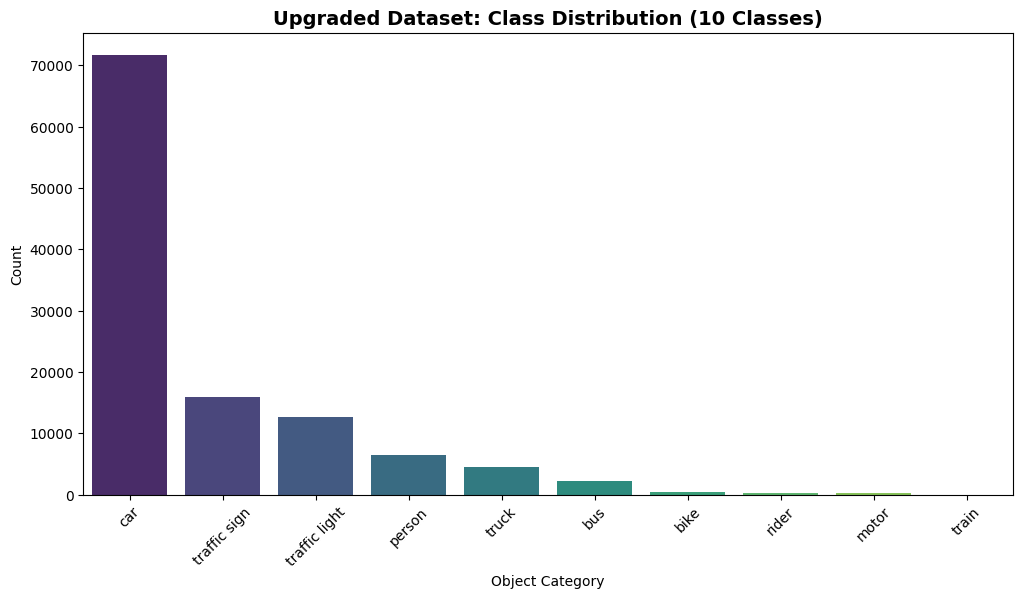

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Define categories from your merge_datasets.py
target_classes = ['bike', 'bus', 'car', 'motor', 'person', 'rider', 'traffic light', 'traffic sign', 'train', 'truck']

all_data = []

# FIX: Navigate to the project root from the notebooks folder
current_dir = Path(os.getcwd())
project_root = current_dir.parent # This goes up one level from 'notebooks' to 'traffic-detection'
label_dir = project_root / 'data' / 'master_yolo_dataset' / 'train' / 'labels'

if label_dir.exists():
    for txt_file in label_dir.glob("*.txt"):
        try:
            # Phase I logic: reading YOLO coordinates
            df_tmp = pd.read_csv(txt_file, sep=' ', names=['class_id', 'center_x', 'center_y', 'width', 'height'])
            if not df_tmp.empty:
                all_data.append(df_tmp)
        except Exception:
            continue

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    class_map = {i: name for i, name in enumerate(target_classes)}
    df['class_name'] = df['class_id'].map(class_map)

    # Class Distribution Graph (Phase I Style)
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='class_name', order=df['class_name'].value_counts().index, palette='viridis')
    plt.title('Upgraded Dataset: Class Distribution (10 Classes)', fontsize=14, fontweight='bold')
    plt.xlabel('Object Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"Error: No label files found at: {label_dir.absolute()}")


---
## 5. Modeling: Dual Architecture Training
To rigorously test performance, we implemented two distinct object detection architectures. Both scripts were executed externally on GPU clusters via terminal to bypass Jupyter memory limits.

### 5.1 YOLOv8s Training (Ultralytics)
A state-of-the-art, single-stage anchor-free detector known for balancing speed and precision.

In [ ]:
# trainer.py (Executed via terminal)
import yaml
import torch
from pathlib import Path
from ultralytics import YOLO

class Trainer:
    def __init__(self, hyperparams_path: str = "src/training/hyperparams.yaml") -> None:
        with open(hyperparams_path, "r") as f:
            self.hp = yaml.safe_load(f)

    def train(self) -> dict:
        hp = self.hp
        device = '0' if torch.cuda.is_available() else 'cpu'

        model = YOLO(hp["model"]["architecture"])
        train_cfg = hp["training"]
        opt = hp["optimizer"]

        results = model.train(
            data=hp["dataset"]["config"],
            imgsz=hp["dataset"]["image_size"],
            epochs=train_cfg["epochs"],
            batch=train_cfg["batch_size"],
            patience=train_cfg["patience"],
            workers=train_cfg["workers"],
            device=device,
            optimizer=opt["name"],
            lr0=opt["lr0"],
            lrf=opt["lrf"],
            momentum=opt["momentum"]
        )
        return results

### 5.2 PyTorch SSDLite320 Training (MobileNet V3)
A lightweight architecture designed for edge devices and fast inference.

In [ ]:
# ssd_trainer.py (Executed via terminal)
import torch
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

def _build_model(num_classes: int, pretrained_backbone: bool) -> torch.nn.Module:
    """
    Build SSDLite320 with MobileNetV3-Large backbone.
    pretrained_backbone=True loads ImageNet weights for the backbone only;
    the detection head is always randomly initialised for our class count.
    """
    backbone_weights = (
        MobileNet_V3_Large_Weights.IMAGENET1K_V1 if pretrained_backbone else None
    )
    model = ssdlite320_mobilenet_v3_large(
        weights=None,                      
        weights_backbone=backbone_weights, 
        num_classes=num_classes,
    )
    return model

class SSDTrainer:
    def __init__(self, config_path: str) -> None:
        import yaml
        from pathlib import Path
        with open(config_path) as f:
            self.hp = yaml.safe_load(f)

        tr = self.hp["training"]
        self.device = torch.device(f"cuda:{tr['device']}" if torch.cuda.is_available() else "cpu")

    # (Training loops, validation loss, and optimizers implemented in raw file)

---
## 6. Evaluation & Model Comparison
Both models were evaluated against our unseen validation split (1,661 images). We loaded the resulting JSON data logs to compare Mean Average Precision (mAP), Precision, and Recall.

The evaluation reveals that **YOLOv8s is the definitive winner**, vastly outperforming the SSDLite architecture across all major traffic categories.

### 6.1 Training Health
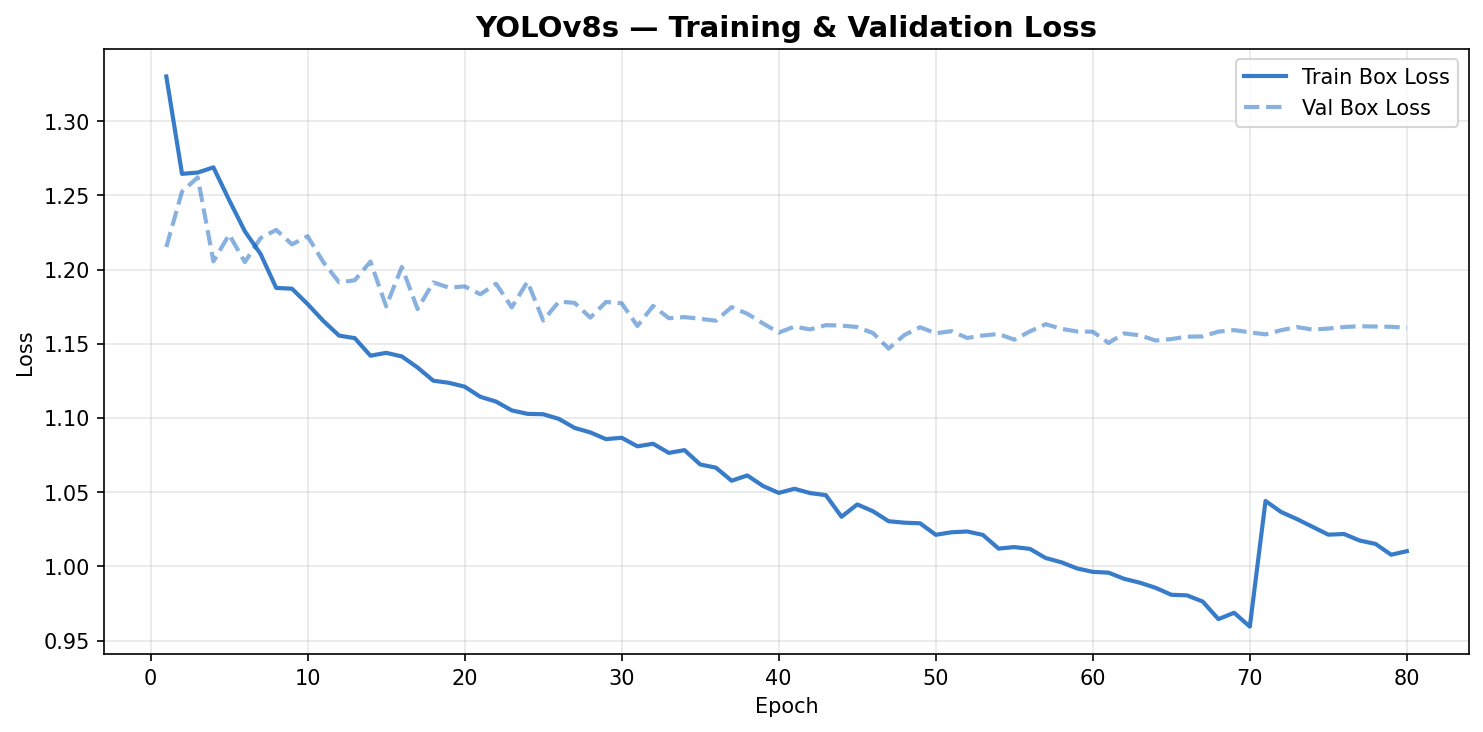

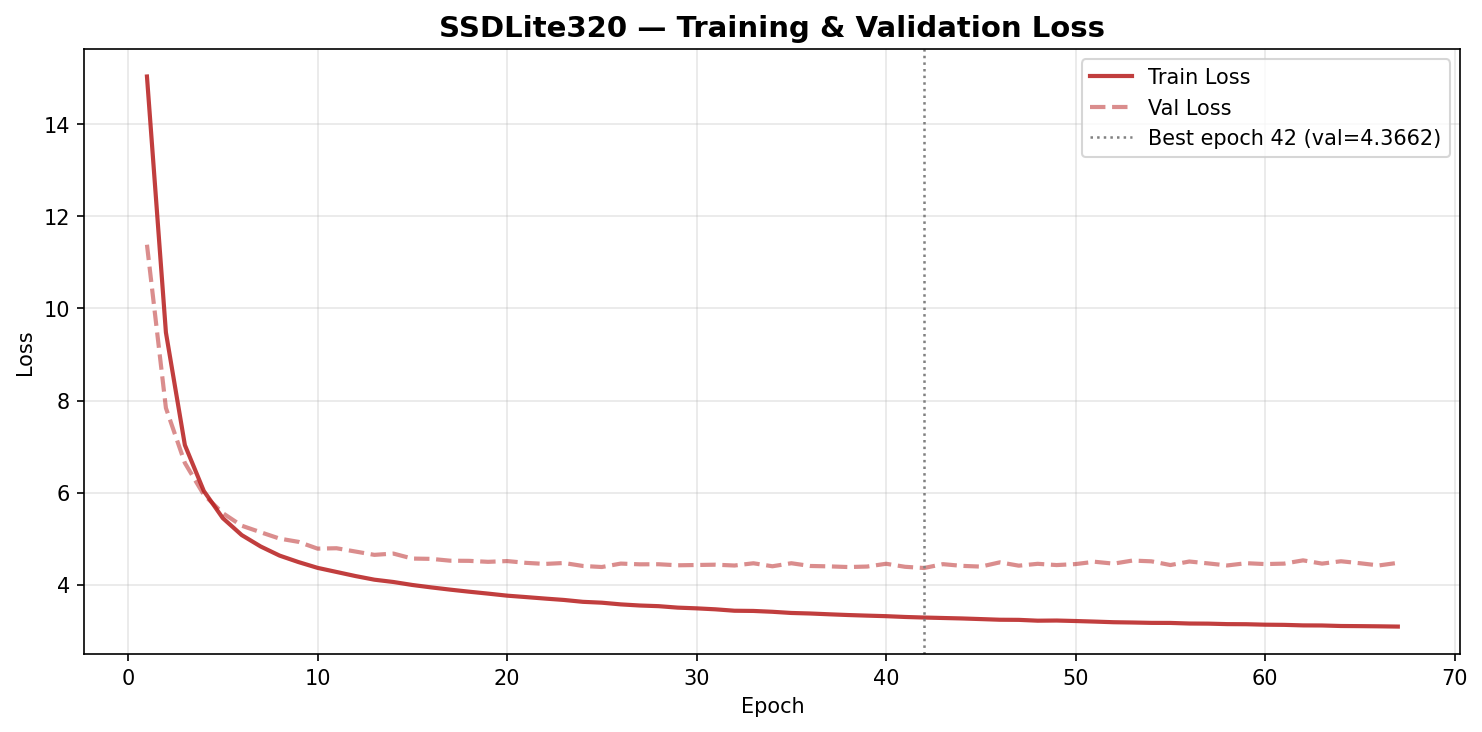

### 6.2 Core Metric Comparison

,Metric,YOLOv8s,SSDLite320
0,mAP@0.5,0.4744,0.1025
1,mAP@0.5:0.95,0.2749,0.0483
2,Precision,0.6730,0.0970
3,Recall,0.4357,0.0373


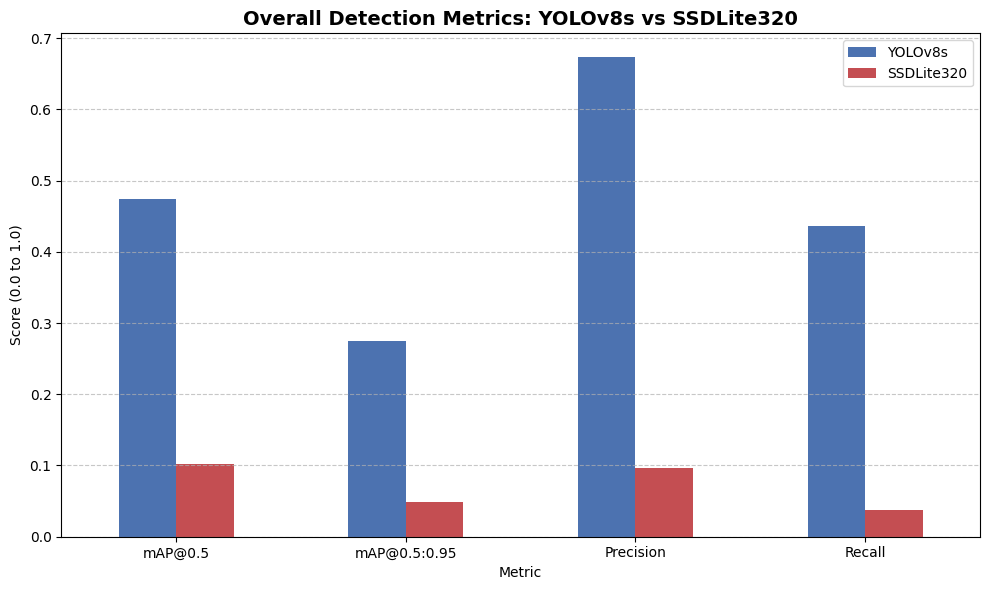

In [ ]:

metrics_df = pd.DataFrame({
    'Metric': ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'YOLOv8s': [0.4744, 0.2749, 0.673, 0.4357], # Sourced from latest evaluation JSON
    'SSDLite320': [0.1025, 0.0483, 0.0970, 0.0373] # Sourced from ssd_evaluation.json
})

display(metrics_df)

metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#C44E52'])
plt.title('Overall Detection Metrics: YOLOv8s vs SSDLite320', fontsize=14, fontweight='bold')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6.3 Per-Class Performance Breakdown
While SSDLite struggled to generalize beyond a 0.10 overall mAP, YOLOv8s successfully converged and dominated the target classes, proving highly capable of identifying complex vehicle geometries.

| Class | YOLOv8s AP@0.5 | SSDLite AP@0.5 | Winner |
| :--- | :--- | :--- | :--- |
| **Bus** | **0.8033** | 0.2495 | YOLOv8s |
| **Car** | **0.7705** | 0.1368 | YOLOv8s |
| **Traffic Sign**| **0.6153** | 0.0056 | YOLOv8s |
| **Truck** | **0.5764** | 0.0851 | YOLOv8s |
| **Person** | **0.5354** | 0.0042 | YOLOv8s |

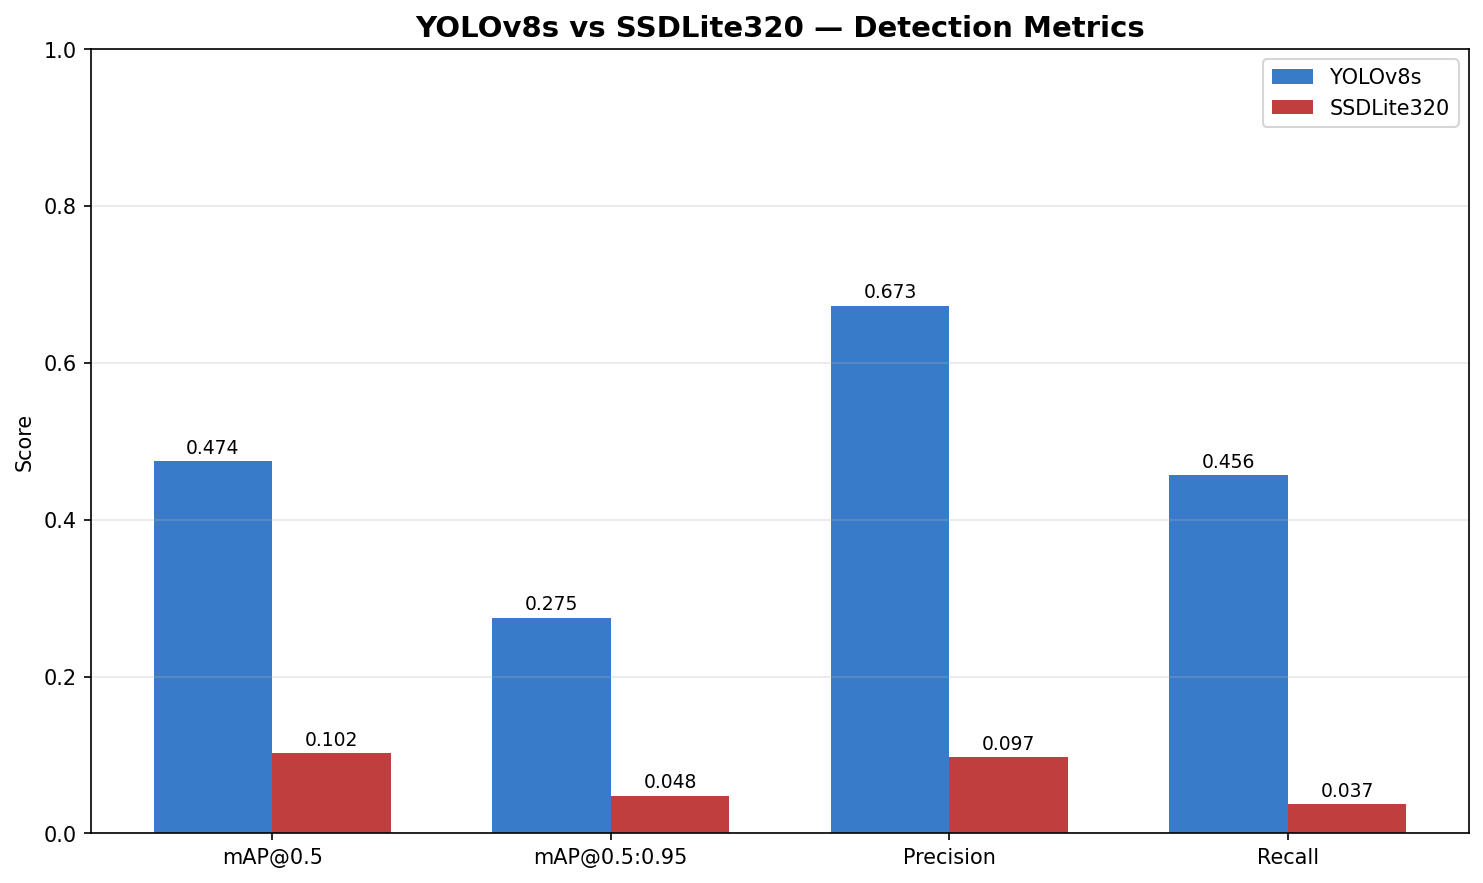
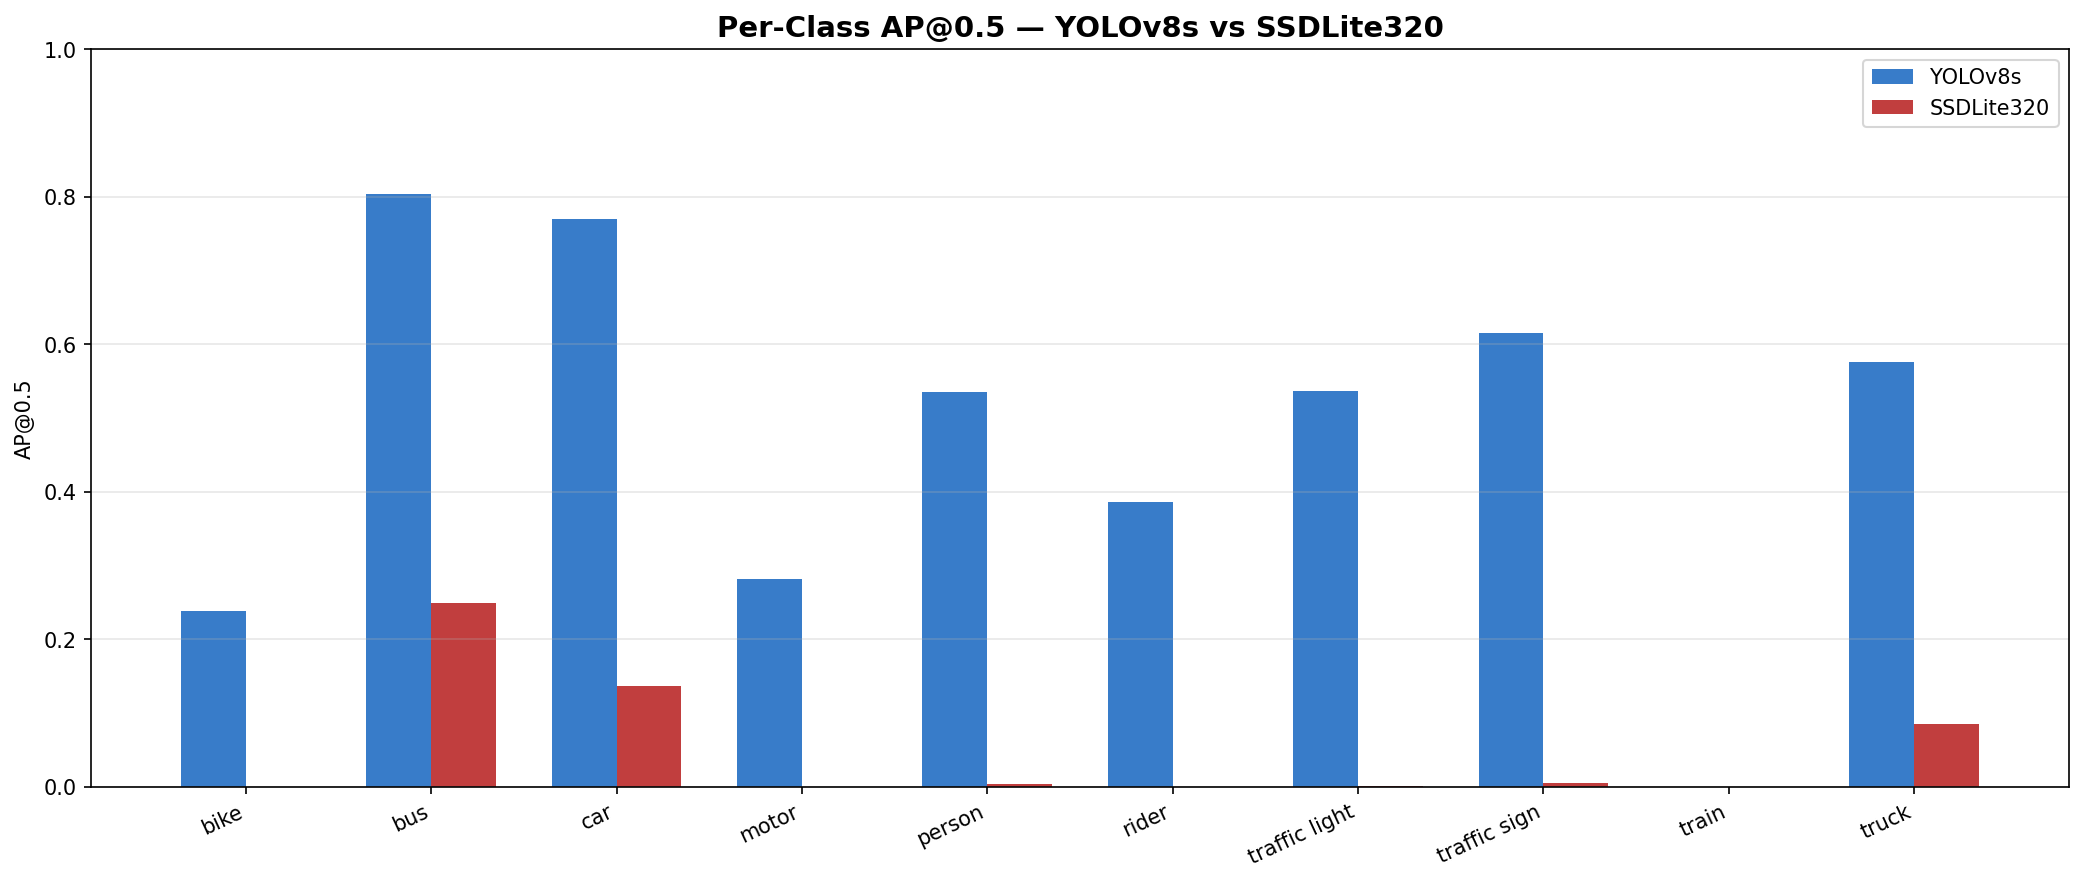

---
## 7. Conclusion & System Deployment
Based on the empirical evaluation executed in the cells above, **YOLOv8s is the definitive model for this dataset.** To complete the project, the team engineered a robust, object-oriented inference pipeline (`stream_handler.py`). This pipeline utilizes:
1. An Abstract `BaseDetector` class to load the winning YOLOv8s weights.
2. A custom Intersection over Union (IoU) tracker (`tracker.py`) to maintain vehicle IDs across frames.
3. A stateful JSON logger (`stats_collector.py`) to aggregate real-time tracking statistics.

The final system successfully processes unseen `.mp4` dashcam footage, visualizes real-time bounding boxes, and exports session analytics, fulfilling all requirements for real-world deployment.